In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from pingouin import wilcoxon
from statsmodels.stats.multitest import multipletests
from scipy.stats import hmean
import numpy as np

sns.set_theme(style="whitegrid")

In [2]:
def compute_statistics(col_name, table_col, condition, baseline_df, df_geg2, table_tex):
  for data in baseline_df['data'].unique():
    stats = pd.DataFrame()
    baseline_acc = baseline_df[baseline_df['data'] == data][col_name]
    for constraint in df_geg2['constraint'].unique():
      geg_acc = df_geg2[(df_geg2['data'] == data) & (df_geg2['constraint'] == constraint)][col_name]
      stat = wilcoxon(baseline_acc.abs(), geg_acc.abs(), alternative=condition)
      stats = pd.concat([stats, pd.DataFrame({'data': [data], 'constraint': [constraint], 'p-val': stat['p-val']})], ignore_index=True)
    stats.loc[:, 'accept'] = multipletests(stats['p-val'], method='holm')[1]
    for _, row in stats.iterrows():
      mask = (table_tex['data'] == data) & (table_tex['constraint'] == row['constraint'])
      indices = table_tex.index[mask].tolist()
      for idx in indices:
        current_val = table_tex.loc[idx, table_col]
        if row['accept'] < 0.05:
          table_tex.loc[idx, table_col] = '\\isBetter ' + current_val
        elif row['accept'] >= 0.9:
          table_tex.loc[idx, table_col] = '\\isWorse ' + current_val
  return table_tex

## RQ1

In [3]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_baseline'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_baseline', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)

In [4]:
grouped = baseline_df.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index()

In [5]:
grouped_baseline = grouped.drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_85928/2910365511.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_baseline = grouped.drop(columns='fold')


In [6]:
df_geg2 = pd.DataFrame()
for file in os.listdir('results_geg_new'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_geg_new', file))
        df['data'] = data
        df_geg2 = pd.concat([df_geg2, df], ignore_index=True)
# df_geg2['statistical_parity'] = df_geg2['statistical_parity']
# df_geg2['equal_opportunity'] = df_geg2['equal_opportunity']
# df_geg2['average_odds'] = df_geg2['average_odds']

In [7]:
df_geg_multi = pd.DataFrame()
for file in os.listdir('results_geg_multi'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_geg_multi', file))
        df['data'] = data
        df_geg_multi = pd.concat([df_geg_multi, df], ignore_index=True)

In [8]:
df_geg_multi['constraint'] = df_geg_multi['constraint'].apply(lambda x: 'GEG-MULTI-SP' if x == 'dp' else ('GEG-MULTI-EO' if x == 'eo' else 'GEG-MULTI-CP'))

In [9]:
grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_85928/157383463.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')


In [10]:
grouped_geg_multi = df_geg_multi.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_85928/3246613307.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_geg_multi = df_geg_multi.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')


In [11]:
full_data = pd.concat([grouped_baseline, grouped_geg, grouped_geg_multi], ignore_index=True)

In [12]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)
full_data['WC-SPD'] = full_data[('wc_statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_statistical_parity', 'std')].round(3).astype(str)
full_data['WC-EOD'] = full_data[('wc_equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_equal_opportunity', 'std')].round(3).astype(str)
full_data['WC-AOD'] = full_data[('wc_average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_average_odds', 'std')].round(3).astype(str)

In [13]:
full_data.sort_values(by=['data', 'constraint'], inplace=True)

In [14]:
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)
# Appiattire le colonne MultiIndex
table_tex.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in table_tex.columns]

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_85928/2769336708.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)


In [15]:
compute_statistics('precision', 'prec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_statistical_parity', 'WC-SPD', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_equal_opportunity', 'WC-EOD', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_average_odds', 'WC-AOD', 'greater', baseline_df, df_geg2, table_tex)

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
28,cmc,GEG-MULTI-CP,0.607$\pm$0.036,0.584$\pm$0.041,0.562$\pm$0.034,0.555$\pm$0.037,0.062$\pm$0.061,0.104$\pm$0.101,0.059$\pm$0.059,0.062$\pm$0.061,0.063$\pm$0.18,0.089$\pm$0.054
29,cmc,GEG-MULTI-EO,0.601$\pm$0.031,0.571$\pm$0.033,0.555$\pm$0.025,0.549$\pm$0.027,0.017$\pm$0.068,0.004$\pm$0.103,-0.001$\pm$0.067,0.017$\pm$0.068,-0.038$\pm$0.179,0.015$\pm$0.107
30,cmc,GEG-MULTI-SP,0.606$\pm$0.033,0.582$\pm$0.037,0.56$\pm$0.032,0.553$\pm$0.033,0.114$\pm$0.066,0.178$\pm$0.129,0.115$\pm$0.075,0.114$\pm$0.066,0.135$\pm$0.204,0.086$\pm$0.117
7,cmc,cp,0.604$\pm$0.031,\isWorse 0.576$\pm$0.042,\isWorse 0.561$\pm$0.036,\isWorse 0.555$\pm$0.038,\isBetter 0.048$\pm$0.045,\isBetter 0.086$\pm$0.149,\isBetter 0.045$\pm$0.072,\isBetter 0.048$\pm$0.045,0.092$\pm$0.179,0.036$\pm$0.101
8,cmc,dp,0.599$\pm$0.031,\isWorse 0.572$\pm$0.036,\isWorse 0.554$\pm$0.026,\isWorse 0.548$\pm$0.028,\isBetter 0.022$\pm$0.079,\isBetter 0.001$\pm$0.074,\isBetter 0.001$\pm$0.069,\isBetter 0.022$\pm$0.079,0.033$\pm$0.132,0.066$\pm$0.09
9,cmc,eo,0.595$\pm$0.036,\isWorse 0.567$\pm$0.04,\isWorse 0.555$\pm$0.032,\isWorse 0.551$\pm$0.034,\isBetter 0.035$\pm$0.054,\isBetter 0.04$\pm$0.114,\isBetter 0.02$\pm$0.052,\isBetter 0.035$\pm$0.054,-0.002$\pm$0.19,0.0$\pm$0.12
0,cmc,lr,0.606$\pm$0.033,0.583$\pm$0.037,0.56$\pm$0.032,0.553$\pm$0.033,0.115$\pm$0.066,0.178$\pm$0.129,0.116$\pm$0.076,0.115$\pm$0.066,0.135$\pm$0.204,0.086$\pm$0.117
31,crime,GEG-MULTI-CP,0.351$\pm$0.04,0.352$\pm$0.032,0.334$\pm$0.032,0.316$\pm$0.034,0.017$\pm$0.115,0.104$\pm$0.162,0.003$\pm$0.102,0.017$\pm$0.115,0.233$\pm$0.231,0.125$\pm$0.135
32,crime,GEG-MULTI-EO,0.407$\pm$0.044,0.388$\pm$0.056,0.391$\pm$0.044,0.375$\pm$0.042,0.202$\pm$0.058,0.143$\pm$0.275,0.109$\pm$0.137,0.202$\pm$0.058,0.152$\pm$0.384,0.08$\pm$0.22
33,crime,GEG-MULTI-SP,0.318$\pm$0.025,0.332$\pm$0.043,0.305$\pm$0.033,0.294$\pm$0.039,-0.094$\pm$0.092,0.04$\pm$0.263,-0.079$\pm$0.149,-0.094$\pm$0.092,0.233$\pm$0.294,0.02$\pm$0.23


In [16]:
compute_statistics('precision', 'prec', 'less', baseline_df, df_geg_multi, table_tex)
compute_statistics('recall', 'rec', 'less', baseline_df, df_geg_multi, table_tex)
compute_statistics('f1_score', 'f1', 'less', baseline_df, df_geg_multi, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', baseline_df, df_geg_multi, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', baseline_df, df_geg_multi, table_tex)
compute_statistics('average_odds', 'aod', 'greater', baseline_df, df_geg_multi, table_tex)
compute_statistics('wc_statistical_parity', 'WC-SPD', 'greater', baseline_df, df_geg_multi, table_tex)
compute_statistics('wc_equal_opportunity', 'WC-EOD', 'greater', baseline_df, df_geg_multi, table_tex)
compute_statistics('wc_average_odds', 'WC-AOD', 'greater', baseline_df, df_geg_multi, table_tex)

/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: Run

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
28,cmc,GEG-MULTI-CP,0.607$\pm$0.036,\isWorse 0.584$\pm$0.041,0.562$\pm$0.034,0.555$\pm$0.037,\isBetter 0.062$\pm$0.061,\isBetter 0.104$\pm$0.101,\isBetter 0.059$\pm$0.059,\isBetter 0.062$\pm$0.061,0.063$\pm$0.18,0.089$\pm$0.054
29,cmc,GEG-MULTI-EO,0.601$\pm$0.031,\isWorse 0.571$\pm$0.033,\isWorse 0.555$\pm$0.025,\isWorse 0.549$\pm$0.027,\isBetter 0.017$\pm$0.068,\isBetter 0.004$\pm$0.103,\isBetter -0.001$\pm$0.067,\isBetter 0.017$\pm$0.068,-0.038$\pm$0.179,0.015$\pm$0.107
30,cmc,GEG-MULTI-SP,0.606$\pm$0.033,\isWorse 0.582$\pm$0.037,\isWorse 0.56$\pm$0.032,\isWorse 0.553$\pm$0.033,0.114$\pm$0.066,\isWorse 0.178$\pm$0.129,0.115$\pm$0.075,0.114$\pm$0.066,\isWorse 0.135$\pm$0.204,0.086$\pm$0.117
7,cmc,cp,0.604$\pm$0.031,\isWorse 0.576$\pm$0.042,\isWorse 0.561$\pm$0.036,\isWorse 0.555$\pm$0.038,\isBetter 0.048$\pm$0.045,\isBetter 0.086$\pm$0.149,\isBetter 0.045$\pm$0.072,\isBetter 0.048$\pm$0.045,0.092$\pm$0.179,0.036$\pm$0.101
8,cmc,dp,0.599$\pm$0.031,\isWorse 0.572$\pm$0.036,\isWorse 0.554$\pm$0.026,\isWorse 0.548$\pm$0.028,\isBetter 0.022$\pm$0.079,\isBetter 0.001$\pm$0.074,\isBetter 0.001$\pm$0.069,\isBetter 0.022$\pm$0.079,0.033$\pm$0.132,0.066$\pm$0.09
9,cmc,eo,0.595$\pm$0.036,\isWorse 0.567$\pm$0.04,\isWorse 0.555$\pm$0.032,\isWorse 0.551$\pm$0.034,\isBetter 0.035$\pm$0.054,\isBetter 0.04$\pm$0.114,\isBetter 0.02$\pm$0.052,\isBetter 0.035$\pm$0.054,-0.002$\pm$0.19,0.0$\pm$0.12
0,cmc,lr,0.606$\pm$0.033,0.583$\pm$0.037,0.56$\pm$0.032,0.553$\pm$0.033,0.115$\pm$0.066,0.178$\pm$0.129,0.116$\pm$0.076,0.115$\pm$0.066,0.135$\pm$0.204,0.086$\pm$0.117
31,crime,GEG-MULTI-CP,0.351$\pm$0.04,\isWorse 0.352$\pm$0.032,\isWorse 0.334$\pm$0.032,\isWorse 0.316$\pm$0.034,\isBetter 0.017$\pm$0.115,\isBetter 0.104$\pm$0.162,\isBetter 0.003$\pm$0.102,\isBetter 0.017$\pm$0.115,\isBetter 0.233$\pm$0.231,\isBetter 0.125$\pm$0.135
32,crime,GEG-MULTI-EO,0.407$\pm$0.044,\isWorse 0.388$\pm$0.056,\isWorse 0.391$\pm$0.044,\isWorse 0.375$\pm$0.042,\isBetter 0.202$\pm$0.058,\isBetter 0.143$\pm$0.275,\isBetter 0.109$\pm$0.137,\isBetter 0.202$\pm$0.058,0.152$\pm$0.384,\isBetter 0.08$\pm$0.22
33,crime,GEG-MULTI-SP,0.318$\pm$0.025,\isWorse 0.332$\pm$0.043,\isWorse 0.305$\pm$0.033,\isWorse 0.294$\pm$0.039,\isBetter -0.094$\pm$0.092,0.04$\pm$0.263,\isBetter -0.079$\pm$0.149,\isBetter -0.094$\pm$0.092,0.233$\pm$0.294,\isBetter 0.02$\pm$0.23


In [17]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
28,cmc,GEG-MULTI-CP,0.607$\pm$0.036,\isWorse 0.584$\pm$0.041,0.562$\pm$0.034,0.555$\pm$0.037,\isBetter 0.062$\pm$0.061,\isBetter 0.104$\pm$0.101,\isBetter 0.059$\pm$0.059,\isBetter 0.062$\pm$0.061,0.063$\pm$0.18,0.089$\pm$0.054
29,cmc,GEG-MULTI-EO,0.601$\pm$0.031,\isWorse 0.571$\pm$0.033,\isWorse 0.555$\pm$0.025,\isWorse 0.549$\pm$0.027,\isBetter 0.017$\pm$0.068,\isBetter 0.004$\pm$0.103,\isBetter -0.001$\pm$0.067,\isBetter 0.017$\pm$0.068,-0.038$\pm$0.179,0.015$\pm$0.107
30,cmc,GEG-MULTI-SP,0.606$\pm$0.033,\isWorse 0.582$\pm$0.037,\isWorse 0.56$\pm$0.032,\isWorse 0.553$\pm$0.033,0.114$\pm$0.066,\isWorse 0.178$\pm$0.129,0.115$\pm$0.075,0.114$\pm$0.066,\isWorse 0.135$\pm$0.204,0.086$\pm$0.117
7,cmc,cp,0.604$\pm$0.031,\isWorse 0.576$\pm$0.042,\isWorse 0.561$\pm$0.036,\isWorse 0.555$\pm$0.038,\isBetter 0.048$\pm$0.045,\isBetter 0.086$\pm$0.149,\isBetter 0.045$\pm$0.072,\isBetter 0.048$\pm$0.045,0.092$\pm$0.179,0.036$\pm$0.101
8,cmc,dp,0.599$\pm$0.031,\isWorse 0.572$\pm$0.036,\isWorse 0.554$\pm$0.026,\isWorse 0.548$\pm$0.028,\isBetter 0.022$\pm$0.079,\isBetter 0.001$\pm$0.074,\isBetter 0.001$\pm$0.069,\isBetter 0.022$\pm$0.079,0.033$\pm$0.132,0.066$\pm$0.09
9,cmc,eo,0.595$\pm$0.036,\isWorse 0.567$\pm$0.04,\isWorse 0.555$\pm$0.032,\isWorse 0.551$\pm$0.034,\isBetter 0.035$\pm$0.054,\isBetter 0.04$\pm$0.114,\isBetter 0.02$\pm$0.052,\isBetter 0.035$\pm$0.054,-0.002$\pm$0.19,0.0$\pm$0.12
0,cmc,lr,0.606$\pm$0.033,0.583$\pm$0.037,0.56$\pm$0.032,0.553$\pm$0.033,0.115$\pm$0.066,0.178$\pm$0.129,0.116$\pm$0.076,0.115$\pm$0.066,0.135$\pm$0.204,0.086$\pm$0.117
31,crime,GEG-MULTI-CP,0.351$\pm$0.04,\isWorse 0.352$\pm$0.032,\isWorse 0.334$\pm$0.032,\isWorse 0.316$\pm$0.034,\isBetter 0.017$\pm$0.115,\isBetter 0.104$\pm$0.162,\isBetter 0.003$\pm$0.102,\isBetter 0.017$\pm$0.115,\isBetter 0.233$\pm$0.231,\isBetter 0.125$\pm$0.135
32,crime,GEG-MULTI-EO,0.407$\pm$0.044,\isWorse 0.388$\pm$0.056,\isWorse 0.391$\pm$0.044,\isWorse 0.375$\pm$0.042,\isBetter 0.202$\pm$0.058,\isBetter 0.143$\pm$0.275,\isBetter 0.109$\pm$0.137,\isBetter 0.202$\pm$0.058,0.152$\pm$0.384,\isBetter 0.08$\pm$0.22
33,crime,GEG-MULTI-SP,0.318$\pm$0.025,\isWorse 0.332$\pm$0.043,\isWorse 0.305$\pm$0.033,\isWorse 0.294$\pm$0.039,\isBetter -0.094$\pm$0.092,0.04$\pm$0.263,\isBetter -0.079$\pm$0.149,\isBetter -0.094$\pm$0.092,0.233$\pm$0.294,\isBetter 0.02$\pm$0.23


In [18]:
table_tex.to_latex('results_summary.tex', index=False, escape=False)

### Pareto Analysis

In [19]:
from itertools import product
from collections import defaultdict

def pareto_front_two(df,acc,fair):
    df = df.sort_values(by=[acc, fair], ascending=[False, True])
    pareto = []
    for i in range(len(df)):
        if not any((abs(df.iloc[i][acc]) <= abs(p[acc]) and
                    abs(df.iloc[i][fair]) >= abs(p[fair])) for p in pareto):
            pareto.append(df.iloc[i])
    return pd.DataFrame(pareto)

def pareto_front_full(df):
    df = df.sort_values(by=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds'], ascending=[False, False, False, False, True, True, True])
    pareto = []
    for i in range(len(df)):
        if not any((df.iloc[i]['accuracy'] <= p['accuracy'] and
                    df.iloc[i]['precision'] <= p['precision'] and
                    df.iloc[i]['recall'] <= p['recall'] and
                    df.iloc[i]['f1_score'] <= p['f1_score'] and
                    abs(df.iloc[i]['statistical_parity']) >= abs(p['statistical_parity']) and
                    abs(df.iloc[i]['equal_opportunity']) >= abs(p['equal_opportunity']) and
                    abs(df.iloc[i]['average_odds']) >= abs(p['average_odds'])) for p in pareto):
            pareto.append(df.iloc[i])
    return pd.DataFrame(pareto)

# df_all = pd.concat([baseline_df, df_geg2, df_geg_multi], ignore_index=True)
df_all = pd.concat([baseline_df, df_geg_multi], ignore_index=True)
datasets = df_all['data'].unique()
# attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
# metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  # if dataset == 'cmc':
  #       continue
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1
df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)
dfs['wc_statistical_parity'].fillna(0, inplace=True)
dfs['wc_equal_opportunity'].fillna(0, inplace=True)
dfs['wc_average_odds'].fillna(0, inplace=True)

dfs['SPD POS'] = dfs.pop('statistical_parity')
dfs['EOD POS'] = dfs.pop('equal_opportunity')
dfs['AOD POS'] = dfs.pop('average_odds')
dfs['SPD'] = dfs.pop('wc_statistical_parity')
dfs['EOD'] = dfs.pop('wc_equal_opportunity')
dfs['AOD'] = dfs.pop('wc_average_odds')

rename_map = {
  "lr": "LR",
  "dp": "GEG-SP",
  "eo": "GEG-EO",
  "cp": "GEG-CP",
  "GEG-MULTI-SP": "GEG-MULTI-SP",
  "GEG-MULTI-EO": "GEG-MULTI-EO",
  "GEG-MULTI-CP": "GEG-MULTI-CP"
}
dfs['SPD POS'].rename(index=rename_map, inplace=True)
dfs['EOD POS'].rename(index=rename_map, inplace=True)
dfs['AOD POS'].rename(index=rename_map, inplace=True)
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)

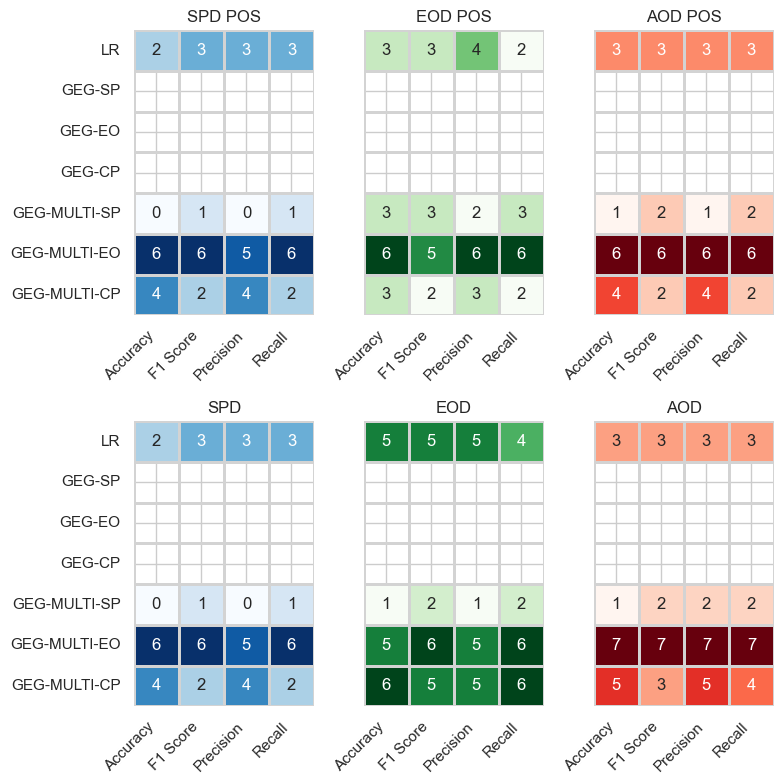

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(8, 8), sharey=True)

# Replace with your real keys
keys = ["SPD POS", "EOD POS", "AOD POS", "SPD", "EOD", "AOD"]
cols = {"SPD POS":"Blues","EOD POS":"Greens","AOD POS":"Reds", "SPD":"Blues","EOD":"Greens","AOD":"Reds"}

dfs['SPD POS'] = dfs['SPD POS'].reindex(['LR', 'GEG-SP', 'GEG-EO', 'GEG-CP', 'GEG-MULTI-SP', 'GEG-MULTI-EO', 'GEG-MULTI-CP'])
dfs['EOD POS'] = dfs['EOD POS'].reindex(['LR', 'GEG-SP', 'GEG-EO', 'GEG-CP', 'GEG-MULTI-SP', 'GEG-MULTI-EO', 'GEG-MULTI-CP'])
dfs['AOD POS'] = dfs['AOD POS'].reindex(['LR', 'GEG-SP', 'GEG-EO', 'GEG-CP', 'GEG-MULTI-SP', 'GEG-MULTI-EO', 'GEG-MULTI-CP'])
dfs['SPD'] = dfs['SPD'].reindex(['LR', 'GEG-SP', 'GEG-EO', 'GEG-CP', 'GEG-MULTI-SP', 'GEG-MULTI-EO', 'GEG-MULTI-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['LR', 'GEG-SP', 'GEG-EO', 'GEG-CP', 'GEG-MULTI-SP', 'GEG-MULTI-EO', 'GEG-MULTI-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['LR', 'GEG-SP', 'GEG-EO', 'GEG-CP', 'GEG-MULTI-SP', 'GEG-MULTI-EO', 'GEG-MULTI-CP'])

for i, (ax, key) in enumerate(zip(axes.flatten(), keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
# plt.savefig("imgs/heatmaps_combined-v1.pdf", bbox_inches="tight")
plt.show()

## RQ3

In [17]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_demv'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_demv', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)
grouped_demv = baseline_df.groupby('data').agg(['mean', 'std']).reset_index()
grouped_demv = grouped_demv.drop(columns='fold')
grouped_demv['constraint'] = 'demv'

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/857907954.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_demv = grouped_demv.drop(columns='fold')


In [18]:
blackbox_df = pd.DataFrame()
for file in os.listdir('results_blackbox'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_blackbox', file))
        df['data'] = data
        blackbox_df = pd.concat([blackbox_df, df], ignore_index=True)
grouped_blackbox = blackbox_df.groupby('data').agg(['mean', 'std']).reset_index()
grouped_blackbox = grouped_blackbox.drop(columns='fold')
grouped_blackbox['constraint'] = 'blackbox'

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/156202595.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_blackbox = grouped_blackbox.drop(columns='fold')


In [19]:
full_data = pd.concat([grouped_demv, grouped_blackbox, grouped_geg], ignore_index=True)

In [20]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)
full_data['WC-SPD'] = full_data[('wc_statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_statistical_parity', 'std')].round(3).astype(str)
full_data['WC-EOD'] = full_data[('wc_equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_equal_opportunity', 'std')].round(3).astype(str)
full_data['WC-AOD'] = full_data[('wc_average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_average_odds', 'std')].round(3).astype(str)
full_data.sort_values(by=['data'], inplace=True)
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)
# Appiattire le colonne MultiIndex
table_tex.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in table_tex.columns]

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/946668475.py:12: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)


In [21]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
0,cmc,demv,0.603$\pm$0.028,0.58$\pm$0.036,0.553$\pm$0.026,0.544$\pm$0.028,0.052$\pm$0.045,0.032$\pm$0.163,0.027$\pm$0.057,0.052$\pm$0.045,-0.031$\pm$0.218,0.027$\pm$0.094
16,cmc,eo,0.59$\pm$0.04,0.563$\pm$0.045,0.549$\pm$0.037,0.543$\pm$0.04,0.05$\pm$0.054,0.071$\pm$0.118,0.038$\pm$0.061,0.05$\pm$0.054,0.015$\pm$0.236,0.011$\pm$0.128
15,cmc,dp,0.597$\pm$0.032,0.569$\pm$0.039,0.552$\pm$0.028,0.545$\pm$0.031,0.01$\pm$0.054,0.021$\pm$0.128,-0.0$\pm$0.069,0.01$\pm$0.054,0.08$\pm$0.19,0.066$\pm$0.114
14,cmc,cp,0.604$\pm$0.035,0.577$\pm$0.044,0.56$\pm$0.039,0.555$\pm$0.041,0.05$\pm$0.044,0.025$\pm$0.169,0.02$\pm$0.054,0.05$\pm$0.044,-0.024$\pm$0.2,0.029$\pm$0.089
7,cmc,blackbox,0.384$\pm$0.071,0.362$\pm$0.071,0.364$\pm$0.073,0.352$\pm$0.072,-0.097$\pm$0.197,-0.096$\pm$0.284,-0.093$\pm$0.232,-0.097$\pm$0.197,-0.103$\pm$0.727,0.036$\pm$0.693
19,crime,eo,0.333$\pm$0.075,0.312$\pm$0.129,0.306$\pm$0.084,0.244$\pm$0.112,0.153$\pm$0.115,0.088$\pm$0.146,0.089$\pm$0.103,0.153$\pm$0.115,0.078$\pm$0.274,0.09$\pm$0.141
18,crime,dp,0.401$\pm$0.032,0.397$\pm$0.024,0.393$\pm$0.033,0.388$\pm$0.028,0.038$\pm$0.065,-0.068$\pm$0.23,-0.067$\pm$0.12,0.038$\pm$0.065,-0.232$\pm$0.447,0.02$\pm$0.334
8,crime,blackbox,0.207$\pm$0.04,0.197$\pm$0.065,0.202$\pm$0.042,0.174$\pm$0.04,-0.403$\pm$0.084,-0.603$\pm$0.175,-0.516$\pm$0.104,-0.403$\pm$0.084,-0.059$\pm$0.697,-0.007$\pm$0.597
17,crime,cp,0.366$\pm$0.04,0.373$\pm$0.041,0.344$\pm$0.034,0.321$\pm$0.043,0.112$\pm$0.081,0.1$\pm$0.236,0.051$\pm$0.118,0.112$\pm$0.081,0.208$\pm$0.308,0.103$\pm$0.187
1,crime,demv,0.457$\pm$0.034,0.423$\pm$0.049,0.433$\pm$0.036,0.406$\pm$0.039,0.343$\pm$0.061,0.249$\pm$0.263,0.221$\pm$0.139,0.343$\pm$0.061,0.23$\pm$0.343,0.136$\pm$0.247


In [22]:
compute_statistics('precision', 'prec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_statistical_parity', 'WC-SPD', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_equal_opportunity', 'WC-EOD', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_average_odds', 'WC-AOD', 'greater', baseline_df, df_geg2, table_tex)

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
0,cmc,demv,0.603$\pm$0.028,0.58$\pm$0.036,0.553$\pm$0.026,0.544$\pm$0.028,0.052$\pm$0.045,0.032$\pm$0.163,0.027$\pm$0.057,0.052$\pm$0.045,-0.031$\pm$0.218,0.027$\pm$0.094
16,cmc,eo,0.59$\pm$0.04,\isWorse 0.563$\pm$0.045,\isWorse 0.549$\pm$0.037,0.543$\pm$0.04,\isWorse 0.05$\pm$0.054,\isWorse 0.071$\pm$0.118,\isWorse 0.038$\pm$0.061,\isWorse 0.05$\pm$0.054,\isWorse 0.015$\pm$0.236,\isWorse 0.011$\pm$0.128
15,cmc,dp,0.597$\pm$0.032,\isWorse 0.569$\pm$0.039,\isWorse 0.552$\pm$0.028,0.545$\pm$0.031,\isWorse 0.01$\pm$0.054,\isWorse 0.021$\pm$0.128,\isWorse -0.0$\pm$0.069,\isWorse 0.01$\pm$0.054,\isWorse 0.08$\pm$0.19,\isWorse 0.066$\pm$0.114
14,cmc,cp,0.604$\pm$0.035,\isWorse 0.577$\pm$0.044,\isWorse 0.56$\pm$0.039,0.555$\pm$0.041,\isWorse 0.05$\pm$0.044,\isWorse 0.025$\pm$0.169,\isWorse 0.02$\pm$0.054,\isWorse 0.05$\pm$0.044,\isWorse -0.024$\pm$0.2,0.029$\pm$0.089
7,cmc,blackbox,0.384$\pm$0.071,0.362$\pm$0.071,0.364$\pm$0.073,0.352$\pm$0.072,-0.097$\pm$0.197,-0.096$\pm$0.284,-0.093$\pm$0.232,-0.097$\pm$0.197,-0.103$\pm$0.727,0.036$\pm$0.693
19,crime,eo,0.333$\pm$0.075,\isWorse 0.312$\pm$0.129,\isWorse 0.306$\pm$0.084,\isWorse 0.244$\pm$0.112,\isBetter 0.153$\pm$0.115,0.088$\pm$0.146,0.089$\pm$0.103,\isBetter 0.153$\pm$0.115,0.078$\pm$0.274,0.09$\pm$0.141
18,crime,dp,0.401$\pm$0.032,\isWorse 0.397$\pm$0.024,\isWorse 0.393$\pm$0.033,\isWorse 0.388$\pm$0.028,\isBetter 0.038$\pm$0.065,-0.068$\pm$0.23,-0.067$\pm$0.12,\isBetter 0.038$\pm$0.065,\isWorse -0.232$\pm$0.447,\isWorse 0.02$\pm$0.334
8,crime,blackbox,0.207$\pm$0.04,0.197$\pm$0.065,0.202$\pm$0.042,0.174$\pm$0.04,-0.403$\pm$0.084,-0.603$\pm$0.175,-0.516$\pm$0.104,-0.403$\pm$0.084,-0.059$\pm$0.697,-0.007$\pm$0.597
17,crime,cp,0.366$\pm$0.04,\isWorse 0.373$\pm$0.041,\isWorse 0.344$\pm$0.034,\isWorse 0.321$\pm$0.043,\isBetter 0.112$\pm$0.081,0.1$\pm$0.236,\isBetter 0.051$\pm$0.118,\isBetter 0.112$\pm$0.081,0.208$\pm$0.308,0.103$\pm$0.187
1,crime,demv,0.457$\pm$0.034,0.423$\pm$0.049,0.433$\pm$0.036,0.406$\pm$0.039,0.343$\pm$0.061,0.249$\pm$0.263,0.221$\pm$0.139,0.343$\pm$0.061,0.23$\pm$0.343,0.136$\pm$0.247


In [23]:
table_tex.to_latex('results_summary_demv.tex', index=False, escape=False)

In [24]:
compute_statistics('precision', 'prec', 'less', blackbox_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', blackbox_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', blackbox_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', blackbox_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', blackbox_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', blackbox_df, df_geg2, table_tex)
compute_statistics('wc_statistical_parity', 'WC-SPD', 'greater', blackbox_df, df_geg2, table_tex)
compute_statistics('wc_equal_opportunity', 'WC-EOD', 'greater', blackbox_df, df_geg2, table_tex)
compute_statistics('wc_average_odds', 'WC-AOD', 'greater', blackbox_df, df_geg2, table_tex)

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
0,cmc,demv,0.603$\pm$0.028,0.58$\pm$0.036,0.553$\pm$0.026,0.544$\pm$0.028,0.052$\pm$0.045,0.032$\pm$0.163,0.027$\pm$0.057,0.052$\pm$0.045,-0.031$\pm$0.218,0.027$\pm$0.094
16,cmc,eo,0.59$\pm$0.04,\isBetter \isWorse 0.563$\pm$0.045,\isBetter \isWorse 0.549$\pm$0.037,\isBetter 0.543$\pm$0.04,\isBetter \isWorse 0.05$\pm$0.054,\isWorse 0.071$\pm$0.118,\isBetter \isWorse 0.038$\pm$0.061,\isBetter \isWorse 0.05$\pm$0.054,\isBetter \isWorse 0.015$\pm$0.236,\isBetter \isWorse 0.011$\pm$0.128
15,cmc,dp,0.597$\pm$0.032,\isBetter \isWorse 0.569$\pm$0.039,\isBetter \isWorse 0.552$\pm$0.028,\isBetter 0.545$\pm$0.031,\isBetter \isWorse 0.01$\pm$0.054,\isWorse 0.021$\pm$0.128,\isBetter \isWorse -0.0$\pm$0.069,\isBetter \isWorse 0.01$\pm$0.054,\isBetter \isWorse 0.08$\pm$0.19,\isBetter \isWorse 0.066$\pm$0.114
14,cmc,cp,0.604$\pm$0.035,\isBetter \isWorse 0.577$\pm$0.044,\isBetter \isWorse 0.56$\pm$0.039,\isBetter 0.555$\pm$0.041,\isBetter \isWorse 0.05$\pm$0.044,\isWorse 0.025$\pm$0.169,\isBetter \isWorse 0.02$\pm$0.054,\isBetter \isWorse 0.05$\pm$0.044,\isBetter \isWorse -0.024$\pm$0.2,\isBetter 0.029$\pm$0.089
7,cmc,blackbox,0.384$\pm$0.071,0.362$\pm$0.071,0.364$\pm$0.073,0.352$\pm$0.072,-0.097$\pm$0.197,-0.096$\pm$0.284,-0.093$\pm$0.232,-0.097$\pm$0.197,-0.103$\pm$0.727,0.036$\pm$0.693
19,crime,eo,0.333$\pm$0.075,\isBetter \isWorse 0.312$\pm$0.129,\isBetter \isWorse 0.306$\pm$0.084,\isBetter \isWorse 0.244$\pm$0.112,\isBetter \isBetter 0.153$\pm$0.115,\isBetter 0.088$\pm$0.146,\isBetter 0.089$\pm$0.103,\isBetter \isBetter 0.153$\pm$0.115,\isBetter 0.078$\pm$0.274,\isBetter 0.09$\pm$0.141
18,crime,dp,0.401$\pm$0.032,\isBetter \isWorse 0.397$\pm$0.024,\isBetter \isWorse 0.393$\pm$0.033,\isBetter \isWorse 0.388$\pm$0.028,\isBetter \isBetter 0.038$\pm$0.065,\isBetter -0.068$\pm$0.23,\isBetter -0.067$\pm$0.12,\isBetter \isBetter 0.038$\pm$0.065,\isBetter \isWorse -0.232$\pm$0.447,\isBetter \isWorse 0.02$\pm$0.334
8,crime,blackbox,0.207$\pm$0.04,0.197$\pm$0.065,0.202$\pm$0.042,0.174$\pm$0.04,-0.403$\pm$0.084,-0.603$\pm$0.175,-0.516$\pm$0.104,-0.403$\pm$0.084,-0.059$\pm$0.697,-0.007$\pm$0.597
17,crime,cp,0.366$\pm$0.04,\isBetter \isWorse 0.373$\pm$0.041,\isBetter \isWorse 0.344$\pm$0.034,\isBetter \isWorse 0.321$\pm$0.043,\isBetter \isBetter 0.112$\pm$0.081,\isBetter 0.1$\pm$0.236,\isBetter \isBetter 0.051$\pm$0.118,\isBetter \isBetter 0.112$\pm$0.081,\isBetter 0.208$\pm$0.308,\isBetter 0.103$\pm$0.187
1,crime,demv,0.457$\pm$0.034,0.423$\pm$0.049,0.433$\pm$0.036,0.406$\pm$0.039,0.343$\pm$0.061,0.249$\pm$0.263,0.221$\pm$0.139,0.343$\pm$0.061,0.23$\pm$0.343,0.136$\pm$0.247


In [25]:
table_tex.to_latex('results_blackbox_comparison.tex', index=False, escape=False)

In [26]:
baseline_df['constraint'] = 'demv'
blackbox_df['constraint'] = 'blackbox'
df_all = pd.concat([baseline_df, blackbox_df, df_geg2], ignore_index=True)

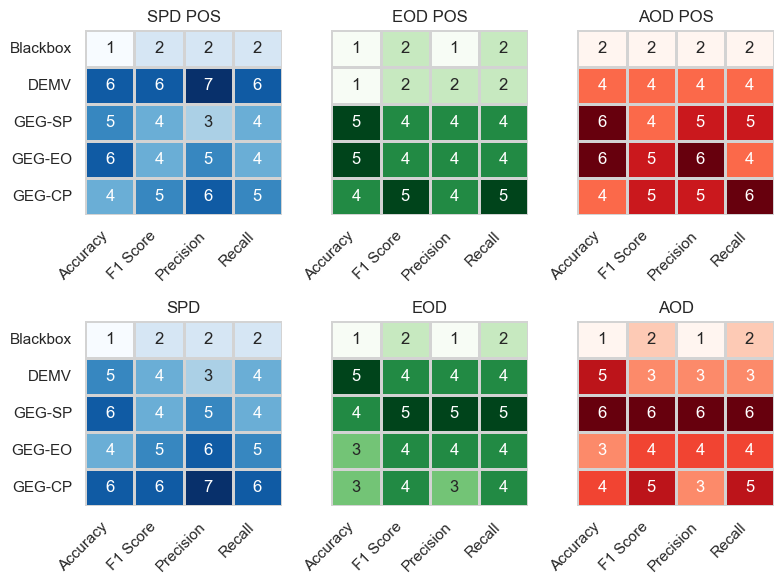

In [27]:
baseline_df['constraint'] = 'demv'
blackbox_df['constraint'] = 'blackbox'
df_all = pd.concat([baseline_df, blackbox_df, df_geg2], ignore_index=True)
datasets = df_all['data'].unique()
#attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
#metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1

df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)
dfs['wc_statistical_parity'].fillna(0, inplace=True)
dfs['wc_equal_opportunity'].fillna(0, inplace=True)
dfs['wc_average_odds'].fillna(0, inplace=True)

dfs['SPD POS'] = dfs.pop('statistical_parity')
dfs['EOD POS'] = dfs.pop('equal_opportunity')
dfs['AOD POS'] = dfs.pop('average_odds')
dfs['SPD'] = dfs.pop('wc_statistical_parity')
dfs['EOD'] = dfs.pop('wc_equal_opportunity')
dfs['AOD'] = dfs.pop('wc_average_odds')
rename_map = {
  "blackbox": "Blackbox",
  "demv": "DEMV",
  "dp": "GEG-SP",
  "eo": "GEG-EO",
  "cp": "GEG-CP",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)
dfs['SPD POS'].rename(index=rename_map, inplace=True)
dfs['EOD POS'].rename(index=rename_map, inplace=True)
dfs['AOD POS'].rename(index=rename_map, inplace=True)

dfs['SPD'] = dfs['SPD'].reindex(['Blackbox', 'DEMV', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['Blackbox', 'DEMV', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['Blackbox', 'DEMV', 'GEG-SP', 'GEG-EO', 'GEG-CP'])

fig, axes = plt.subplots(2, 3, figsize=(8, 6), sharey=True)

# Replace with your real keys
keys = ["SPD POS", "EOD POS", "AOD POS", "SPD", "EOD", "AOD"]
cols = {"SPD":"Blues","EOD":"Greens","AOD":"Reds", "SPD POS":"Blues","EOD POS":"Greens","AOD POS":"Reds"}
for i, (ax, key) in enumerate(zip(axes.flatten(), keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-v2.pdf", bbox_inches="tight")
plt.show()

## RQ2 

In [28]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_baseline_rq2'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_baseline_rq2', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)

In [29]:
grouped = baseline_df.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index()

In [30]:
grouped_baseline = grouped.drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/2910365511.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_baseline = grouped.drop(columns='fold')


In [31]:
df_geg2 = pd.DataFrame()
for file in os.listdir('results_geg_rq2'):
    if file.endswith('.csv'):
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_geg_rq2', file))
        df['data'] = data
        df_geg2 = pd.concat([df_geg2, df], ignore_index=True)

In [32]:
grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/157383463.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')


In [33]:
grouped_baseline['constraint'] = 'baseline'

In [34]:
full_data = pd.concat([grouped_baseline.assign(constraint='baseline'), grouped_geg], ignore_index=True)

In [35]:
full_data.head()

data constraint  accuracy           precision              recall  \
                          mean       std      mean       std      mean   
0   adult   baseline  0.835779  0.003980  0.784151  0.007322  0.744502   
1  compas   baseline  0.675209  0.021380  0.675343  0.019898  0.666093   
2  german   baseline  0.752000  0.050509  0.705072  0.073177  0.671076   
3   adult         cp  0.828862  0.006761  0.789714  0.016506  0.705332   
4   adult         dp  0.821978  0.006085  0.770826  0.012393  0.704226   

             f1_score            ... equal_opportunity           average_odds  \
        std      mean       std  ...              mean       std         mean   
0  0.006577  0.760457  0.006354  ...         -0.140238  0.068418    -0.112488   
1  0.019814  0.665794  0.021166  ...         -0.102123  0.030810    -0.149917   
2  0.063392  0.678572  0.065526  ...         -0.177970  0.165344    -0.172655   
3  0.007798  0.730988  0.008628  ...          0.105111  0.111135     0.045989   
4  0.008116  0.726252  0.009199  ...          0.276583  0.072403     0.153022   

            wc_statistical_parity           wc_equal_opportunity            \
        std                  mean       std                 mean       std   
0  0.034111             -0.185497  0.015477            -0.098245  0.130607   
1  0.041596             -0.173967  0.040158             0.197711  0.062793   
2  0.143716             -0.206228  0.136137             0.015847  0.311763   
3  0.066176             -0.077404  0.036556             0.109090  0.107359   
4  0.041931             -0.018740  0.022166             0.276583  0.072403   

  wc_average_odds            
             mean       std  
0        0.012478  0.122678  
1        0.002482  0.163388  
2       -0.045294  0.226929  
3       -0.001892  0.082007  
4        0.109023  0.120702  

[5 rows x 22 columns]

In [36]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)
full_data['spd_wc'] = full_data[('wc_statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_statistical_parity', 'std')].round(3).astype(str)
full_data['eod_wc'] = full_data[('wc_equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_equal_opportunity', 'std')].round(3).astype(str)
full_data['aod_wc'] = full_data[('wc_average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_average_odds', 'std')].round(3).astype(str)

In [37]:
full_data.sort_values(by=['data', 'constraint'], inplace=True)
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)
# Appiattire le colonne MultiIndex
table_tex.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in table_tex.columns]

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/1987305015.py:2: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)


In [38]:
table_tex


,data,constraint,acc,prec,rec,f1,spd,eod,aod,spd_wc,eod_wc,aod_wc
0,adult,baseline,0.836$\pm$0.004,0.784$\pm$0.007,0.745$\pm$0.007,0.76$\pm$0.006,-0.185$\pm$0.015,-0.14$\pm$0.068,-0.112$\pm$0.034,-0.185$\pm$0.015,-0.098$\pm$0.131,0.012$\pm$0.123
3,adult,cp,0.829$\pm$0.007,0.79$\pm$0.017,0.705$\pm$0.008,0.731$\pm$0.009,-0.077$\pm$0.037,0.105$\pm$0.111,0.046$\pm$0.066,-0.077$\pm$0.037,0.109$\pm$0.107,-0.002$\pm$0.082
4,adult,dp,0.822$\pm$0.006,0.771$\pm$0.012,0.704$\pm$0.008,0.726$\pm$0.009,-0.019$\pm$0.022,0.277$\pm$0.072,0.153$\pm$0.042,-0.019$\pm$0.022,0.277$\pm$0.072,0.109$\pm$0.121
5,adult,eo,0.827$\pm$0.007,0.775$\pm$0.013,0.723$\pm$0.01,0.742$\pm$0.01,-0.067$\pm$0.036,0.168$\pm$0.104,0.083$\pm$0.061,-0.067$\pm$0.036,0.168$\pm$0.104,-0.004$\pm$0.107
1,compas,baseline,0.675$\pm$0.021,0.675$\pm$0.02,0.666$\pm$0.02,0.666$\pm$0.021,-0.174$\pm$0.04,-0.102$\pm$0.031,-0.15$\pm$0.042,-0.174$\pm$0.04,0.198$\pm$0.063,0.002$\pm$0.163
6,compas,cp,0.67$\pm$0.02,0.67$\pm$0.019,0.66$\pm$0.018,0.66$\pm$0.019,-0.053$\pm$0.063,0.008$\pm$0.046,-0.028$\pm$0.064,-0.053$\pm$0.063,0.073$\pm$0.086,-0.033$\pm$0.061
7,compas,dp,0.667$\pm$0.019,0.667$\pm$0.019,0.657$\pm$0.017,0.656$\pm$0.018,-0.007$\pm$0.081,0.05$\pm$0.081,0.018$\pm$0.077,-0.007$\pm$0.081,0.073$\pm$0.096,0.001$\pm$0.08
8,compas,eo,0.667$\pm$0.018,0.667$\pm$0.019,0.657$\pm$0.017,0.657$\pm$0.018,-0.016$\pm$0.059,0.052$\pm$0.068,0.008$\pm$0.058,-0.016$\pm$0.059,0.088$\pm$0.045,-0.027$\pm$0.052
2,german,baseline,0.752$\pm$0.051,0.705$\pm$0.073,0.671$\pm$0.063,0.679$\pm$0.066,-0.206$\pm$0.136,-0.178$\pm$0.165,-0.173$\pm$0.144,-0.206$\pm$0.136,0.016$\pm$0.312,-0.045$\pm$0.227
9,german,cp,0.746$\pm$0.06,0.698$\pm$0.086,0.66$\pm$0.066,0.67$\pm$0.073,-0.064$\pm$0.176,-0.059$\pm$0.181,-0.026$\pm$0.199,-0.064$\pm$0.176,-0.059$\pm$0.321,0.019$\pm$0.2


In [39]:
compute_statistics('accuracy', 'acc', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('precision', 'prec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_statistical_parity', 'spd_wc', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_equal_opportunity', 'eod_wc', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_average_odds', 'aod_wc', 'greater', baseline_df, df_geg2, table_tex)

,data,constraint,acc,prec,rec,f1,spd,eod,aod,spd_wc,eod_wc,aod_wc
0,adult,baseline,0.836$\pm$0.004,0.784$\pm$0.007,0.745$\pm$0.007,0.76$\pm$0.006,-0.185$\pm$0.015,-0.14$\pm$0.068,-0.112$\pm$0.034,-0.185$\pm$0.015,-0.098$\pm$0.131,0.012$\pm$0.123
3,adult,cp,\isWorse 0.829$\pm$0.007,0.79$\pm$0.017,\isWorse 0.705$\pm$0.008,\isWorse 0.731$\pm$0.009,\isBetter -0.077$\pm$0.037,\isWorse 0.105$\pm$0.111,0.046$\pm$0.066,\isBetter -0.077$\pm$0.037,0.109$\pm$0.107,-0.002$\pm$0.082
4,adult,dp,\isWorse 0.822$\pm$0.006,\isWorse 0.771$\pm$0.012,\isWorse 0.704$\pm$0.008,\isWorse 0.726$\pm$0.009,\isBetter -0.019$\pm$0.022,\isWorse 0.277$\pm$0.072,\isWorse 0.153$\pm$0.042,\isBetter -0.019$\pm$0.022,\isWorse 0.277$\pm$0.072,\isWorse 0.109$\pm$0.121
5,adult,eo,\isWorse 0.827$\pm$0.007,\isWorse 0.775$\pm$0.013,\isWorse 0.723$\pm$0.01,\isWorse 0.742$\pm$0.01,\isBetter -0.067$\pm$0.036,\isWorse 0.168$\pm$0.104,0.083$\pm$0.061,\isBetter -0.067$\pm$0.036,\isWorse 0.168$\pm$0.104,-0.004$\pm$0.107
1,compas,baseline,0.675$\pm$0.021,0.675$\pm$0.02,0.666$\pm$0.02,0.666$\pm$0.021,-0.174$\pm$0.04,-0.102$\pm$0.031,-0.15$\pm$0.042,-0.174$\pm$0.04,0.198$\pm$0.063,0.002$\pm$0.163
6,compas,cp,\isWorse 0.67$\pm$0.02,\isWorse 0.67$\pm$0.019,\isWorse 0.66$\pm$0.018,\isWorse 0.66$\pm$0.019,\isBetter -0.053$\pm$0.063,\isBetter 0.008$\pm$0.046,\isBetter -0.028$\pm$0.064,\isBetter -0.053$\pm$0.063,\isBetter 0.073$\pm$0.086,\isBetter -0.033$\pm$0.061
7,compas,dp,\isWorse 0.667$\pm$0.019,\isWorse 0.667$\pm$0.019,\isWorse 0.657$\pm$0.017,\isWorse 0.656$\pm$0.018,\isBetter -0.007$\pm$0.081,0.05$\pm$0.081,\isBetter 0.018$\pm$0.077,\isBetter -0.007$\pm$0.081,\isBetter 0.073$\pm$0.096,\isBetter 0.001$\pm$0.08
8,compas,eo,\isWorse 0.667$\pm$0.018,\isWorse 0.667$\pm$0.019,\isWorse 0.657$\pm$0.017,\isWorse 0.657$\pm$0.018,\isBetter -0.016$\pm$0.059,0.052$\pm$0.068,\isBetter 0.008$\pm$0.058,\isBetter -0.016$\pm$0.059,\isBetter 0.088$\pm$0.045,\isBetter -0.027$\pm$0.052
2,german,baseline,0.752$\pm$0.051,0.705$\pm$0.073,0.671$\pm$0.063,0.679$\pm$0.066,-0.206$\pm$0.136,-0.178$\pm$0.165,-0.173$\pm$0.144,-0.206$\pm$0.136,0.016$\pm$0.312,-0.045$\pm$0.227
9,german,cp,\isWorse 0.746$\pm$0.06,\isWorse 0.698$\pm$0.086,\isWorse 0.66$\pm$0.066,\isWorse 0.67$\pm$0.073,-0.064$\pm$0.176,-0.059$\pm$0.181,-0.026$\pm$0.199,-0.064$\pm$0.176,\isWorse -0.059$\pm$0.321,0.019$\pm$0.2


In [40]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod,spd_wc,eod_wc,aod_wc
0,adult,baseline,0.836$\pm$0.004,0.784$\pm$0.007,0.745$\pm$0.007,0.76$\pm$0.006,-0.185$\pm$0.015,-0.14$\pm$0.068,-0.112$\pm$0.034,-0.185$\pm$0.015,-0.098$\pm$0.131,0.012$\pm$0.123
3,adult,cp,\isWorse 0.829$\pm$0.007,0.79$\pm$0.017,\isWorse 0.705$\pm$0.008,\isWorse 0.731$\pm$0.009,\isBetter -0.077$\pm$0.037,\isWorse 0.105$\pm$0.111,0.046$\pm$0.066,\isBetter -0.077$\pm$0.037,0.109$\pm$0.107,-0.002$\pm$0.082
4,adult,dp,\isWorse 0.822$\pm$0.006,\isWorse 0.771$\pm$0.012,\isWorse 0.704$\pm$0.008,\isWorse 0.726$\pm$0.009,\isBetter -0.019$\pm$0.022,\isWorse 0.277$\pm$0.072,\isWorse 0.153$\pm$0.042,\isBetter -0.019$\pm$0.022,\isWorse 0.277$\pm$0.072,\isWorse 0.109$\pm$0.121
5,adult,eo,\isWorse 0.827$\pm$0.007,\isWorse 0.775$\pm$0.013,\isWorse 0.723$\pm$0.01,\isWorse 0.742$\pm$0.01,\isBetter -0.067$\pm$0.036,\isWorse 0.168$\pm$0.104,0.083$\pm$0.061,\isBetter -0.067$\pm$0.036,\isWorse 0.168$\pm$0.104,-0.004$\pm$0.107
1,compas,baseline,0.675$\pm$0.021,0.675$\pm$0.02,0.666$\pm$0.02,0.666$\pm$0.021,-0.174$\pm$0.04,-0.102$\pm$0.031,-0.15$\pm$0.042,-0.174$\pm$0.04,0.198$\pm$0.063,0.002$\pm$0.163
6,compas,cp,\isWorse 0.67$\pm$0.02,\isWorse 0.67$\pm$0.019,\isWorse 0.66$\pm$0.018,\isWorse 0.66$\pm$0.019,\isBetter -0.053$\pm$0.063,\isBetter 0.008$\pm$0.046,\isBetter -0.028$\pm$0.064,\isBetter -0.053$\pm$0.063,\isBetter 0.073$\pm$0.086,\isBetter -0.033$\pm$0.061
7,compas,dp,\isWorse 0.667$\pm$0.019,\isWorse 0.667$\pm$0.019,\isWorse 0.657$\pm$0.017,\isWorse 0.656$\pm$0.018,\isBetter -0.007$\pm$0.081,0.05$\pm$0.081,\isBetter 0.018$\pm$0.077,\isBetter -0.007$\pm$0.081,\isBetter 0.073$\pm$0.096,\isBetter 0.001$\pm$0.08
8,compas,eo,\isWorse 0.667$\pm$0.018,\isWorse 0.667$\pm$0.019,\isWorse 0.657$\pm$0.017,\isWorse 0.657$\pm$0.018,\isBetter -0.016$\pm$0.059,0.052$\pm$0.068,\isBetter 0.008$\pm$0.058,\isBetter -0.016$\pm$0.059,\isBetter 0.088$\pm$0.045,\isBetter -0.027$\pm$0.052
2,german,baseline,0.752$\pm$0.051,0.705$\pm$0.073,0.671$\pm$0.063,0.679$\pm$0.066,-0.206$\pm$0.136,-0.178$\pm$0.165,-0.173$\pm$0.144,-0.206$\pm$0.136,0.016$\pm$0.312,-0.045$\pm$0.227
9,german,cp,\isWorse 0.746$\pm$0.06,\isWorse 0.698$\pm$0.086,\isWorse 0.66$\pm$0.066,\isWorse 0.67$\pm$0.073,-0.064$\pm$0.176,-0.059$\pm$0.181,-0.026$\pm$0.199,-0.064$\pm$0.176,\isWorse -0.059$\pm$0.321,0.019$\pm$0.2


In [41]:
table_tex.to_latex('results_summary_rq2.tex', index=False, escape=False)

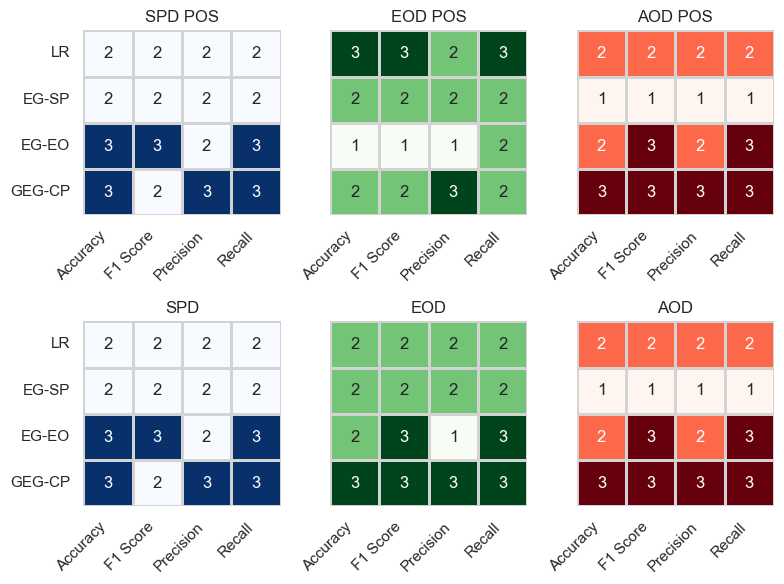

In [42]:
baseline_df['constraint'] = 'LR'
df_all = pd.concat([baseline_df, df_geg2], ignore_index=True)

datasets = df_all['data'].unique()
#attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
#metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1

df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)
dfs['wc_statistical_parity'].fillna(0, inplace=True)
dfs['wc_equal_opportunity'].fillna(0, inplace=True)
dfs['wc_average_odds'].fillna(0, inplace=True)


dfs['SPD'] = dfs.pop('wc_statistical_parity')
dfs['EOD'] = dfs.pop('wc_equal_opportunity')
dfs['AOD'] = dfs.pop('wc_average_odds')
dfs['SPD POS'] = dfs.pop('statistical_parity')
dfs['EOD POS'] = dfs.pop('equal_opportunity')
dfs['AOD POS'] = dfs.pop('average_odds')
rename_map = {
  "dp": "EG-SP",
  "eo": "EG-EO",
  "cp": "GEG-CP",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)
dfs['SPD POS'].rename(index=rename_map, inplace=True)
dfs['EOD POS'].rename(index=rename_map, inplace=True)
dfs['AOD POS'].rename(index=rename_map, inplace=True)

dfs['SPD'] = dfs['SPD'].reindex(['LR', 'EG-SP', 'EG-EO', 'GEG-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['LR', 'EG-SP', 'EG-EO', 'GEG-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['LR', 'EG-SP', 'EG-EO', 'GEG-CP'])
dfs['SPD POS'] = dfs['SPD POS'].reindex(['LR', 'EG-SP', 'EG-EO', 'GEG-CP'])
dfs['EOD POS'] = dfs['EOD POS'].reindex(['LR', 'EG-SP', 'EG-EO', 'GEG-CP'])
dfs['AOD POS'] = dfs['AOD POS'].reindex(['LR', 'EG-SP', 'EG-EO', 'GEG-CP'])

fig, axes = plt.subplots(2, 3, figsize=(8, 6), sharey=True)

# Replace with your real keys
keys = ["SPD POS", "EOD POS", "AOD POS", "SPD", "EOD", "AOD"]
cols = {"SPD":"Blues","EOD":"Greens","AOD":"Reds", "SPD POS":"Blues","EOD POS":"Greens","AOD POS":"Reds"}
for i, (ax, key) in enumerate(zip(axes.flatten(), keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-v3.pdf", bbox_inches="tight")
plt.show()

## RQ4

### Random Forest

In [43]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_models'):
    if file.endswith('.csv') and '_rf' in file:
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_models', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)

In [44]:
grouped = baseline_df.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index()

In [45]:
grouped_baseline = grouped.drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/2910365511.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_baseline = grouped.drop(columns='fold')


In [46]:
df_geg2 = pd.DataFrame()
for file in os.listdir('results_geg_rq4'):
    if file.endswith('.csv') and '_rf' in file:
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_geg_rq4', file))
        df['data'] = data
        df_geg2 = pd.concat([df_geg2, df], ignore_index=True)

In [47]:
grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/157383463.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')


In [48]:
grouped_baseline['constraint'] = 'baseline'

In [49]:
full_data = pd.concat([grouped_baseline.assign(constraint='baseline'), grouped_geg], ignore_index=True)

In [50]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)
full_data['WC-SPD'] = full_data[('wc_statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_statistical_parity', 'std')].round(3).astype(str)
full_data['WC-EOD'] = full_data[('wc_equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_equal_opportunity', 'std')].round(3).astype(str)
full_data['WC-AOD'] = full_data[('wc_average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_average_odds', 'std')].round(3).astype(str)

In [51]:
full_data.sort_values(by=['data', 'constraint'], inplace=True)

In [52]:
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)
# Appiattire le colonne MultiIndex
table_tex.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in table_tex.columns]

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/2769336708.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)


In [53]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
0,cmc,baseline,0.976$\pm$0.014,0.974$\pm$0.012,0.972$\pm$0.015,0.973$\pm$0.014,0.129$\pm$0.082,-0.016$\pm$0.137,-0.002$\pm$0.072,0.129$\pm$0.082,-0.05$\pm$0.146,-0.025$\pm$0.071
7,cmc,cp,0.8$\pm$0.059,0.836$\pm$0.03,0.836$\pm$0.044,0.795$\pm$0.061,0.089$\pm$0.124,0.022$\pm$0.075,-0.002$\pm$0.074,0.089$\pm$0.124,-0.028$\pm$0.201,-0.023$\pm$0.106
8,cmc,dp,0.872$\pm$0.024,0.869$\pm$0.028,0.883$\pm$0.022,0.862$\pm$0.03,0.014$\pm$0.08,0.01$\pm$0.091,-0.067$\pm$0.056,0.014$\pm$0.08,0.193$\pm$0.043,0.043$\pm$0.109
9,cmc,eo,0.982$\pm$0.01,0.983$\pm$0.008,0.98$\pm$0.012,0.981$\pm$0.01,0.151$\pm$0.084,0.033$\pm$0.079,0.026$\pm$0.04,0.151$\pm$0.084,-0.018$\pm$0.119,-0.01$\pm$0.059
1,crime,baseline,0.518$\pm$0.036,0.49$\pm$0.035,0.494$\pm$0.026,0.482$\pm$0.029,0.422$\pm$0.055,0.426$\pm$0.2,0.332$\pm$0.109,0.422$\pm$0.055,0.163$\pm$0.537,0.172$\pm$0.339
10,crime,cp,0.414$\pm$0.026,0.436$\pm$0.036,0.383$\pm$0.023,0.363$\pm$0.027,0.18$\pm$0.048,0.349$\pm$0.139,0.176$\pm$0.087,0.18$\pm$0.048,0.178$\pm$0.403,0.085$\pm$0.224
11,crime,dp,0.432$\pm$0.033,0.43$\pm$0.042,0.406$\pm$0.023,0.388$\pm$0.032,0.148$\pm$0.064,0.202$\pm$0.175,0.087$\pm$0.084,0.148$\pm$0.064,0.25$\pm$0.37,0.043$\pm$0.202
12,crime,eo,0.496$\pm$0.031,0.465$\pm$0.03,0.475$\pm$0.021,0.462$\pm$0.026,0.423$\pm$0.05,0.461$\pm$0.197,0.352$\pm$0.109,0.423$\pm$0.05,0.257$\pm$0.507,0.203$\pm$0.331
2,drug,baseline,0.681$\pm$0.021,0.608$\pm$0.024,0.599$\pm$0.02,0.6$\pm$0.019,0.156$\pm$0.11,0.17$\pm$0.217,0.115$\pm$0.122,0.156$\pm$0.11,-0.168$\pm$0.374,-0.14$\pm$0.195
13,drug,cp,0.642$\pm$0.026,0.553$\pm$0.043,0.571$\pm$0.034,0.532$\pm$0.032,0.078$\pm$0.126,0.086$\pm$0.158,0.03$\pm$0.109,0.078$\pm$0.126,0.075$\pm$0.218,0.032$\pm$0.14


In [54]:
compute_statistics('accuracy', 'acc', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('precision', 'prec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_statistical_parity', 'WC-SPD', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_equal_opportunity', 'WC-EOD', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_average_odds', 'WC-AOD', 'greater', baseline_df, df_geg2, table_tex)

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
0,cmc,baseline,0.976$\pm$0.014,0.974$\pm$0.012,0.972$\pm$0.015,0.973$\pm$0.014,0.129$\pm$0.082,-0.016$\pm$0.137,-0.002$\pm$0.072,0.129$\pm$0.082,-0.05$\pm$0.146,-0.025$\pm$0.071
7,cmc,cp,\isWorse 0.8$\pm$0.059,\isWorse 0.836$\pm$0.03,\isWorse 0.836$\pm$0.044,\isWorse 0.795$\pm$0.061,0.089$\pm$0.124,\isBetter 0.022$\pm$0.075,-0.002$\pm$0.074,0.089$\pm$0.124,\isWorse -0.028$\pm$0.201,\isWorse -0.023$\pm$0.106
8,cmc,dp,\isWorse 0.872$\pm$0.024,\isWorse 0.869$\pm$0.028,\isWorse 0.883$\pm$0.022,\isWorse 0.862$\pm$0.03,0.014$\pm$0.08,0.01$\pm$0.091,-0.067$\pm$0.056,0.014$\pm$0.08,\isWorse 0.193$\pm$0.043,\isWorse 0.043$\pm$0.109
9,cmc,eo,\isBetter 0.982$\pm$0.01,\isBetter 0.983$\pm$0.008,0.98$\pm$0.012,\isBetter 0.981$\pm$0.01,\isWorse 0.151$\pm$0.084,0.033$\pm$0.079,0.026$\pm$0.04,\isWorse 0.151$\pm$0.084,-0.018$\pm$0.119,-0.01$\pm$0.059
1,crime,baseline,0.518$\pm$0.036,0.49$\pm$0.035,0.494$\pm$0.026,0.482$\pm$0.029,0.422$\pm$0.055,0.426$\pm$0.2,0.332$\pm$0.109,0.422$\pm$0.055,0.163$\pm$0.537,0.172$\pm$0.339
10,crime,cp,\isWorse 0.414$\pm$0.026,\isWorse 0.436$\pm$0.036,\isWorse 0.383$\pm$0.023,\isWorse 0.363$\pm$0.027,\isBetter 0.18$\pm$0.048,0.349$\pm$0.139,\isBetter 0.176$\pm$0.087,\isBetter 0.18$\pm$0.048,0.178$\pm$0.403,\isBetter 0.085$\pm$0.224
11,crime,dp,\isWorse 0.432$\pm$0.033,\isWorse 0.43$\pm$0.042,\isWorse 0.406$\pm$0.023,\isWorse 0.388$\pm$0.032,\isBetter 0.148$\pm$0.064,\isBetter 0.202$\pm$0.175,\isBetter 0.087$\pm$0.084,\isBetter 0.148$\pm$0.064,0.25$\pm$0.37,\isBetter 0.043$\pm$0.202
12,crime,eo,\isWorse 0.496$\pm$0.031,\isWorse 0.465$\pm$0.03,\isWorse 0.475$\pm$0.021,\isWorse 0.462$\pm$0.026,0.423$\pm$0.05,\isWorse 0.461$\pm$0.197,\isWorse 0.352$\pm$0.109,0.423$\pm$0.05,\isWorse 0.257$\pm$0.507,0.203$\pm$0.331
2,drug,baseline,0.681$\pm$0.021,0.608$\pm$0.024,0.599$\pm$0.02,0.6$\pm$0.019,0.156$\pm$0.11,0.17$\pm$0.217,0.115$\pm$0.122,0.156$\pm$0.11,-0.168$\pm$0.374,-0.14$\pm$0.195
13,drug,cp,\isWorse 0.642$\pm$0.026,\isWorse 0.553$\pm$0.043,\isWorse 0.571$\pm$0.034,\isWorse 0.532$\pm$0.032,0.078$\pm$0.126,0.086$\pm$0.158,0.03$\pm$0.109,0.078$\pm$0.126,\isBetter 0.075$\pm$0.218,\isBetter 0.032$\pm$0.14


In [55]:
table_tex.to_latex('results_summary_rq4_rf.tex', index=False, escape=False)

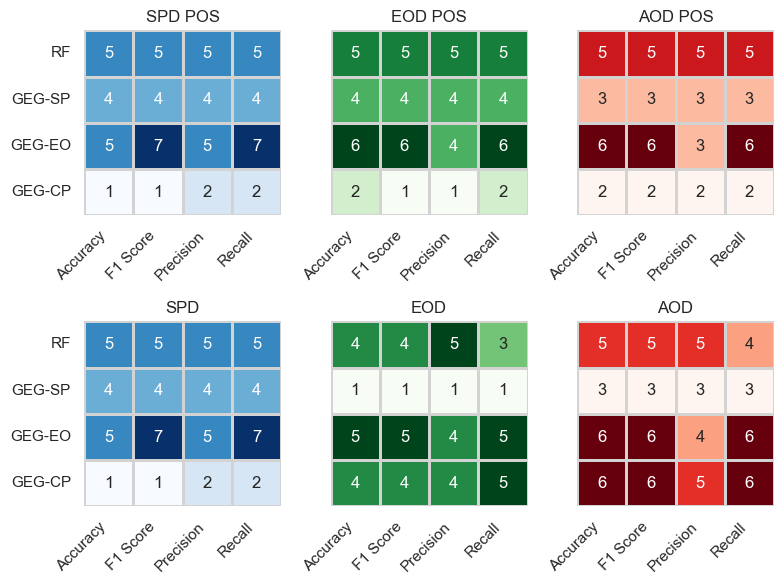

In [56]:
baseline_df['constraint'] = 'RF'
df_all = pd.concat([baseline_df, df_geg2], ignore_index=True)

datasets = df_all['data'].unique()
#attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
#metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1

df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)
dfs['wc_statistical_parity'].fillna(0, inplace=True)
dfs['wc_equal_opportunity'].fillna(0, inplace=True)
dfs['wc_average_odds'].fillna(0, inplace=True)

dfs['SPD'] = dfs.pop('wc_statistical_parity')
dfs['EOD'] = dfs.pop('wc_equal_opportunity')
dfs['AOD'] = dfs.pop('wc_average_odds')
dfs['SPD POS'] = dfs.pop('statistical_parity')
dfs['EOD POS'] = dfs.pop('equal_opportunity')
dfs['AOD POS'] = dfs.pop('average_odds')
rename_map = {
  "dp": "GEG-SP",
  "eo": "GEG-EO",
  "cp": "GEG-CP",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)
dfs['SPD POS'].rename(index=rename_map, inplace=True)
dfs['EOD POS'].rename(index=rename_map, inplace=True)
dfs['AOD POS'].rename(index=rename_map, inplace=True)

dfs['SPD'] = dfs['SPD'].reindex(['RF', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['RF', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['RF', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['SPD POS'] = dfs['SPD POS'].reindex(['RF', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['EOD POS'] = dfs['EOD POS'].reindex(['RF', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['AOD POS'] = dfs['AOD POS'].reindex(['RF', 'GEG-SP', 'GEG-EO', 'GEG-CP'])

fig, axes = plt.subplots(2, 3, figsize=(8, 6), sharey=True)

# Replace with your real keys
keys = ["SPD POS", "EOD POS", "AOD POS", "SPD", "EOD", "AOD"]
cols = {"SPD":"Blues","EOD":"Greens","AOD":"Reds", "SPD POS":"Blues","EOD POS":"Greens","AOD POS":"Reds"}
for i, (ax, key) in enumerate(zip(axes.flatten(), keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-v4.pdf", bbox_inches="tight")
plt.show()

## Gradient Boosting

In [57]:
baseline_df = pd.DataFrame()
for file in os.listdir('results_models'):
    if file.endswith('.csv') and '_xgb' in file:
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_models', file))
        df['data'] = data
        baseline_df = pd.concat([baseline_df, df], ignore_index=True)

In [58]:
grouped = baseline_df.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index()

In [59]:
grouped_baseline = grouped.drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/2910365511.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_baseline = grouped.drop(columns='fold')


In [60]:
df_geg2 = pd.DataFrame()
for file in os.listdir('results_geg_rq4'):
    if file.endswith('.csv') and '_xgb' in file:
        data = file.split('_')[0]
        df = pd.read_csv(os.path.join('results_geg_rq4', file))
        df['data'] = data
        df_geg2 = pd.concat([df_geg2, df], ignore_index=True)

In [61]:
grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/157383463.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  grouped_geg = df_geg2.groupby(['data', 'constraint']).agg(['mean', 'std']).reset_index().drop(columns='fold')


In [62]:
grouped_baseline['constraint'] = 'baseline'

In [63]:
full_data = pd.concat([grouped_baseline.assign(constraint='baseline'), grouped_geg], ignore_index=True)

In [64]:
full_data['acc'] = full_data[('accuracy', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('accuracy', 'std')].round(3).astype(str)
full_data['prec'] = full_data[('precision', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('precision', 'std')].round(3).astype(str)
full_data['rec'] = full_data[('recall', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('recall', 'std')].round(3).astype(str)
full_data['f1'] = full_data[('f1_score', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('f1_score', 'std')].round(3).astype(str)
full_data['spd'] = full_data[('statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('statistical_parity', 'std')].round(3).astype(str)
full_data['eod'] = full_data[('equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('equal_opportunity', 'std')].round(3).astype(str)
full_data['aod'] = full_data[('average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('average_odds', 'std')].round(3).astype(str)
full_data['WC-SPD'] = full_data[('wc_statistical_parity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_statistical_parity', 'std')].round(3).astype(str)
full_data['WC-EOD'] = full_data[('wc_equal_opportunity', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_equal_opportunity', 'std')].round(3).astype(str)
full_data['WC-AOD'] = full_data[('wc_average_odds', 'mean')].round(3).astype(str) + '$\pm$' + full_data[('wc_average_odds', 'std')].round(3).astype(str)

In [65]:
full_data.sort_values(by=['data', 'constraint'], inplace=True)

In [66]:
table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)
# Appiattire le colonne MultiIndex
table_tex.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in table_tex.columns]

/var/folders/4c/mgvn0dc97_9gst9l7jbv9n640000gn/T/ipykernel_39788/2769336708.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  table_tex = full_data.drop(columns=['accuracy', 'precision', 'recall', 'f1_score', 'statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds'], axis=1)


In [67]:
table_tex

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
0,cmc,baseline,0.996$\pm$0.005,0.995$\pm$0.006,0.996$\pm$0.005,0.995$\pm$0.005,0.134$\pm$0.104,0.011$\pm$0.017,0.004$\pm$0.008,0.134$\pm$0.104,0.014$\pm$0.017,0.007$\pm$0.008
7,cmc,cp,0.79$\pm$0.058,0.839$\pm$0.031,0.832$\pm$0.039,0.787$\pm$0.057,0.071$\pm$0.142,0.007$\pm$0.014,-0.021$\pm$0.071,0.071$\pm$0.142,0.043$\pm$0.165,-0.016$\pm$0.094
8,cmc,dp,0.886$\pm$0.041,0.888$\pm$0.035,0.901$\pm$0.035,0.878$\pm$0.044,0.005$\pm$0.12,0.011$\pm$0.017,-0.077$\pm$0.033,0.005$\pm$0.12,0.197$\pm$0.061,0.098$\pm$0.031
9,cmc,eo,0.996$\pm$0.005,0.995$\pm$0.006,0.996$\pm$0.005,0.995$\pm$0.005,0.134$\pm$0.104,0.011$\pm$0.017,0.004$\pm$0.008,0.134$\pm$0.104,0.014$\pm$0.017,0.007$\pm$0.008
1,crime,baseline,0.491$\pm$0.05,0.462$\pm$0.054,0.471$\pm$0.045,0.462$\pm$0.049,0.41$\pm$0.028,0.532$\pm$0.208,0.375$\pm$0.093,0.41$\pm$0.028,0.292$\pm$0.543,0.242$\pm$0.328
10,crime,cp,0.374$\pm$0.043,0.416$\pm$0.044,0.349$\pm$0.029,0.328$\pm$0.037,0.181$\pm$0.063,0.286$\pm$0.262,0.175$\pm$0.108,0.181$\pm$0.063,0.109$\pm$0.43,0.059$\pm$0.231
11,crime,dp,0.428$\pm$0.028,0.434$\pm$0.03,0.41$\pm$0.021,0.406$\pm$0.025,0.025$\pm$0.058,0.088$\pm$0.234,-0.037$\pm$0.104,0.025$\pm$0.058,0.231$\pm$0.333,0.086$\pm$0.22
12,crime,eo,0.483$\pm$0.043,0.458$\pm$0.042,0.463$\pm$0.037,0.454$\pm$0.039,0.331$\pm$0.041,0.348$\pm$0.195,0.255$\pm$0.094,0.331$\pm$0.041,-0.054$\pm$0.541,-0.02$\pm$0.344
2,drug,baseline,0.676$\pm$0.032,0.606$\pm$0.033,0.601$\pm$0.028,0.599$\pm$0.03,0.167$\pm$0.13,0.18$\pm$0.156,0.127$\pm$0.115,0.167$\pm$0.13,-0.246$\pm$0.295,-0.145$\pm$0.19
13,drug,cp,0.657$\pm$0.042,0.579$\pm$0.046,0.577$\pm$0.039,0.573$\pm$0.042,0.041$\pm$0.111,-0.033$\pm$0.224,-0.017$\pm$0.104,0.041$\pm$0.111,-0.098$\pm$0.374,-0.086$\pm$0.168


In [68]:
compute_statistics('precision', 'prec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('recall', 'rec', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('f1_score', 'f1', 'less', baseline_df, df_geg2, table_tex)
compute_statistics('statistical_parity', 'spd', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('equal_opportunity', 'eod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('average_odds', 'aod', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_statistical_parity', 'WC-SPD', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_equal_opportunity', 'WC-EOD', 'greater', baseline_df, df_geg2, table_tex)
compute_statistics('wc_average_odds', 'WC-AOD', 'greater', baseline_df, df_geg2, table_tex)


/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/pingouin/nonparametric.py:493: RuntimeWarning: invalid value encountered in scalar divide
  rbc = r_plus / rsum - r_minus / rsum
/Users/giord/miniconda3/envs/ds/lib/python3.10/site-packages/scipy/stats/_wilcox

,data,constraint,acc,prec,rec,f1,spd,eod,aod,WC-SPD,WC-EOD,WC-AOD
0,cmc,baseline,0.996$\pm$0.005,0.995$\pm$0.006,0.996$\pm$0.005,0.995$\pm$0.005,0.134$\pm$0.104,0.011$\pm$0.017,0.004$\pm$0.008,0.134$\pm$0.104,0.014$\pm$0.017,0.007$\pm$0.008
7,cmc,cp,0.79$\pm$0.058,\isWorse 0.839$\pm$0.031,\isWorse 0.832$\pm$0.039,\isWorse 0.787$\pm$0.057,0.071$\pm$0.142,\isWorse 0.007$\pm$0.014,\isWorse -0.021$\pm$0.071,0.071$\pm$0.142,\isWorse 0.043$\pm$0.165,\isWorse -0.016$\pm$0.094
8,cmc,dp,0.886$\pm$0.041,\isWorse 0.888$\pm$0.035,\isWorse 0.901$\pm$0.035,\isWorse 0.878$\pm$0.044,0.005$\pm$0.12,\isWorse 0.011$\pm$0.017,\isWorse -0.077$\pm$0.033,0.005$\pm$0.12,\isWorse 0.197$\pm$0.061,\isWorse 0.098$\pm$0.031
9,cmc,eo,0.996$\pm$0.005,\isWorse 0.995$\pm$0.006,\isWorse 0.996$\pm$0.005,\isWorse 0.995$\pm$0.005,\isWorse 0.134$\pm$0.104,\isWorse 0.011$\pm$0.017,\isWorse 0.004$\pm$0.008,\isWorse 0.134$\pm$0.104,\isWorse 0.014$\pm$0.017,\isWorse 0.007$\pm$0.008
1,crime,baseline,0.491$\pm$0.05,0.462$\pm$0.054,0.471$\pm$0.045,0.462$\pm$0.049,0.41$\pm$0.028,0.532$\pm$0.208,0.375$\pm$0.093,0.41$\pm$0.028,0.292$\pm$0.543,0.242$\pm$0.328
10,crime,cp,0.374$\pm$0.043,\isWorse 0.416$\pm$0.044,\isWorse 0.349$\pm$0.029,\isWorse 0.328$\pm$0.037,\isBetter 0.181$\pm$0.063,\isBetter 0.286$\pm$0.262,\isBetter 0.175$\pm$0.108,\isBetter 0.181$\pm$0.063,\isBetter 0.109$\pm$0.43,\isBetter 0.059$\pm$0.231
11,crime,dp,0.428$\pm$0.028,\isWorse 0.434$\pm$0.03,\isWorse 0.41$\pm$0.021,\isWorse 0.406$\pm$0.025,\isBetter 0.025$\pm$0.058,\isBetter 0.088$\pm$0.234,\isBetter -0.037$\pm$0.104,\isBetter 0.025$\pm$0.058,\isBetter 0.231$\pm$0.333,\isBetter 0.086$\pm$0.22
12,crime,eo,0.483$\pm$0.043,\isWorse 0.458$\pm$0.042,\isWorse 0.463$\pm$0.037,\isWorse 0.454$\pm$0.039,\isBetter 0.331$\pm$0.041,\isBetter 0.348$\pm$0.195,\isBetter 0.255$\pm$0.094,\isBetter 0.331$\pm$0.041,\isBetter -0.054$\pm$0.541,\isBetter -0.02$\pm$0.344
2,drug,baseline,0.676$\pm$0.032,0.606$\pm$0.033,0.601$\pm$0.028,0.599$\pm$0.03,0.167$\pm$0.13,0.18$\pm$0.156,0.127$\pm$0.115,0.167$\pm$0.13,-0.246$\pm$0.295,-0.145$\pm$0.19
13,drug,cp,0.657$\pm$0.042,\isWorse 0.579$\pm$0.046,\isWorse 0.577$\pm$0.039,\isWorse 0.573$\pm$0.042,\isBetter 0.041$\pm$0.111,-0.033$\pm$0.224,-0.017$\pm$0.104,\isBetter 0.041$\pm$0.111,-0.098$\pm$0.374,-0.086$\pm$0.168


In [69]:
table_tex.to_latex('results_summary_rq4_xgb.tex', index=False, escape=False)

In [70]:
pareto_data

defaultdict(int, {'RF': 24, 'eo': 17, 'dp': 20, 'cp': 5})

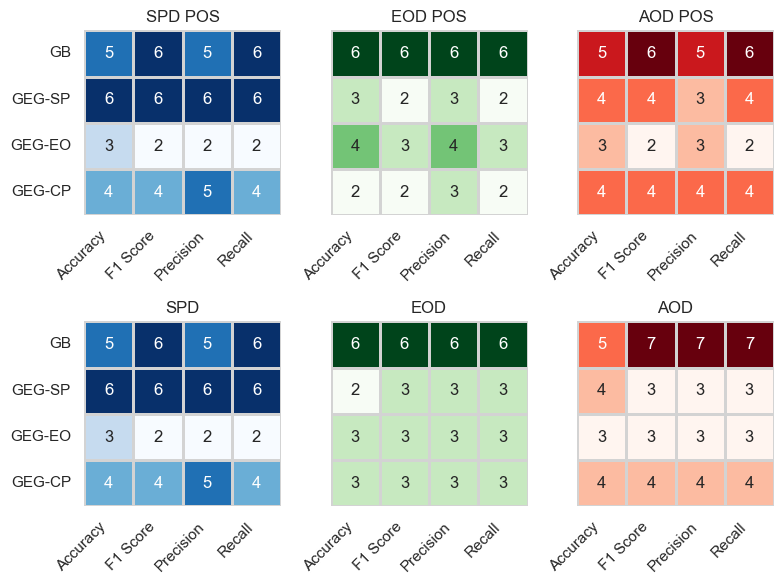

In [71]:
baseline_df['constraint'] = 'GB'
df_all = pd.concat([baseline_df, df_geg2], ignore_index=True)

datasets = df_all['data'].unique()
#attrs = ["age","race","sex"]
metricsAcc = ['accuracy', 'precision', 'recall', 'f1_score']
#metricsAcc = ['MCC']
metricsFair = ['statistical_parity', 'equal_opportunity', 'average_odds', 'wc_statistical_parity', 'wc_equal_opportunity', 'wc_average_odds']
paretoPresent = defaultdict(int)
for dataset in datasets:
  # if dataset == 'cmc' or dataset == 'obesity' or dataset == 'law':
  #     continue
  pareto_data = defaultdict(int)
  for mAcc,mFair in product(metricsAcc,metricsFair):
    #filtered = grouped[(grouped["data"]==dataset) & (grouped["attr"]==attr)]
    filtered = df_all[(df_all["data"]==dataset)]
    if not len(filtered):
        continue
    pareto = pareto_front_two(filtered,mAcc,mFair)
    for x in pareto['constraint'].value_counts().keys():
        paretoPresent[(x,mAcc,mFair)] += 1
        pareto_data[x] += 1

df_all = pd.DataFrame(
    [(k[0], k[1], k[2], v) for k, v in paretoPresent.items()],
    columns=["method", "acc", "fair", "value"]
)
uniqueMethods = sorted(df_all["method"].unique())
df_all = df_all.sort_values('method')
# Create pivot tables for each metric2, reindex to include all methods, fill missing with 0
dfs = {}
df_all = df_all.sort_values('method')
for m2 in df_all["fair"].unique():
    pivot = df_all[df_all["fair"] == m2].pivot(
        index="method", columns="acc", values="value"
    )
    dfs[m2] = pivot.reindex(uniqueMethods, fill_value=np.nan)

dfs['statistical_parity'].fillna(0, inplace=True)
dfs['equal_opportunity'].fillna(0, inplace=True)
dfs['average_odds'].fillna(0, inplace=True)
dfs['wc_statistical_parity'].fillna(0, inplace=True)
dfs['wc_equal_opportunity'].fillna(0, inplace=True)
dfs['wc_average_odds'].fillna(0, inplace=True)

dfs['SPD'] = dfs.pop('wc_statistical_parity')
dfs['EOD'] = dfs.pop('wc_equal_opportunity')
dfs['AOD'] = dfs.pop('wc_average_odds')
dfs['SPD POS'] = dfs.pop('statistical_parity')
dfs['EOD POS'] = dfs.pop('equal_opportunity')
dfs['AOD POS'] = dfs.pop('average_odds')
rename_map = {
  "dp": "GEG-SP",
  "eo": "GEG-EO",
  "cp": "GEG-CP",
}
dfs['SPD'].rename(index=rename_map, inplace=True)
dfs['EOD'].rename(index=rename_map, inplace=True)
dfs['AOD'].rename(index=rename_map, inplace=True)
dfs['SPD POS'].rename(index=rename_map, inplace=True)
dfs['EOD POS'].rename(index=rename_map, inplace=True)
dfs['AOD POS'].rename(index=rename_map, inplace=True)

dfs['SPD'] = dfs['SPD'].reindex(['GB', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['EOD'] = dfs['EOD'].reindex(['GB', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['AOD'] = dfs['AOD'].reindex(['GB', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['SPD POS'] = dfs['SPD POS'].reindex(['GB', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['EOD POS'] = dfs['EOD POS'].reindex(['GB', 'GEG-SP', 'GEG-EO', 'GEG-CP'])
dfs['AOD POS'] = dfs['AOD POS'].reindex(['GB', 'GEG-SP', 'GEG-EO', 'GEG-CP'])

fig, axes = plt.subplots(2, 3, figsize=(8, 6), sharey=True)

# Replace with your real keys
keys = ["SPD POS", "EOD POS", "AOD POS", "SPD", "EOD", "AOD"]
cols = {"SPD POS":"Blues","EOD POS":"Greens","AOD POS":"Reds", "SPD":"Blues","EOD":"Greens","AOD":"Reds"}
for i, (ax, key) in enumerate(zip(axes.flatten(), keys)):
    sns.heatmap(
        dfs[key],
        cmap=cols[key],
        linewidths=1,
        linecolor="lightgrey",
        annot=True,
        cbar=False,
        ax=ax
    )
    
    # Remove x-axis labels
    ax.set_xlabel(None)
    ax.set_ylabel("")  
    ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'], rotation=45, ha="right")
    ax.set_title(key, fontsize=12)

plt.tight_layout()
plt.savefig("imgs/heatmaps_combined-v5.pdf", bbox_inches="tight")
plt.show()

In [24]:
# Compute mean time for each approach
mean_times = full_times.groupby('approach')['time'].mean()

# Calculate percentage variation relative to baseline
baseline_mean = mean_times['baseline']
percentage_variation = ((mean_times - baseline_mean) / baseline_mean) * 100

print("Mean execution times:")
print(mean_times)
print("\nPercentage variation relative to baseline:")
print(percentage_variation)

Mean execution times:
approach
baseline     0.922841
cp           6.583524
dp          11.356527
eo          11.363324
Name: time, dtype: float64

Percentage variation relative to baseline:
approach
baseline       0.000000
cp           613.397427
dp          1130.604850
eo          1131.341362
Name: time, dtype: float64
